In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')



In [2]:
df = pd.read_csv('../data/synthetic_data/historical_dispatch.csv')


df['planned_dispatch_date'] = pd.to_datetime(df['planned_dispatch_date'])

# Aggregate daily demand per product
daily_demand = df.groupby(
    ['planned_dispatch_date', 'product']
)['quantity_tonnes'].sum().reset_index()

daily_demand.columns = ['date', 'product', 'quantity']

print(f" Date range: {daily_demand['date'].min()} "
      f"to {daily_demand['date'].max()}")
print(f" Products: {daily_demand['product'].unique()}")
print(f" Total records: {len(daily_demand)}")
daily_demand.head(10)

 Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
 Products: ['CR Coil' 'HR Coil' 'Semis' 'Plate' 'Structurals' 'Wire Rod' 'TMT Bar']
 Total records: 1390


,date,product,quantity
0,2023-01-01,CR Coil,2145.82
1,2023-01-01,HR Coil,5752.54
2,2023-01-01,Semis,5284.79
3,2023-01-02,HR Coil,2122.67
4,2023-01-02,Plate,1941.81
5,2023-01-02,Semis,2214.04
6,2023-01-03,HR Coil,2521.42
7,2023-01-03,Structurals,3477.92
8,2023-01-03,Wire Rod,2671.05
9,2023-01-04,CR Coil,2612.11


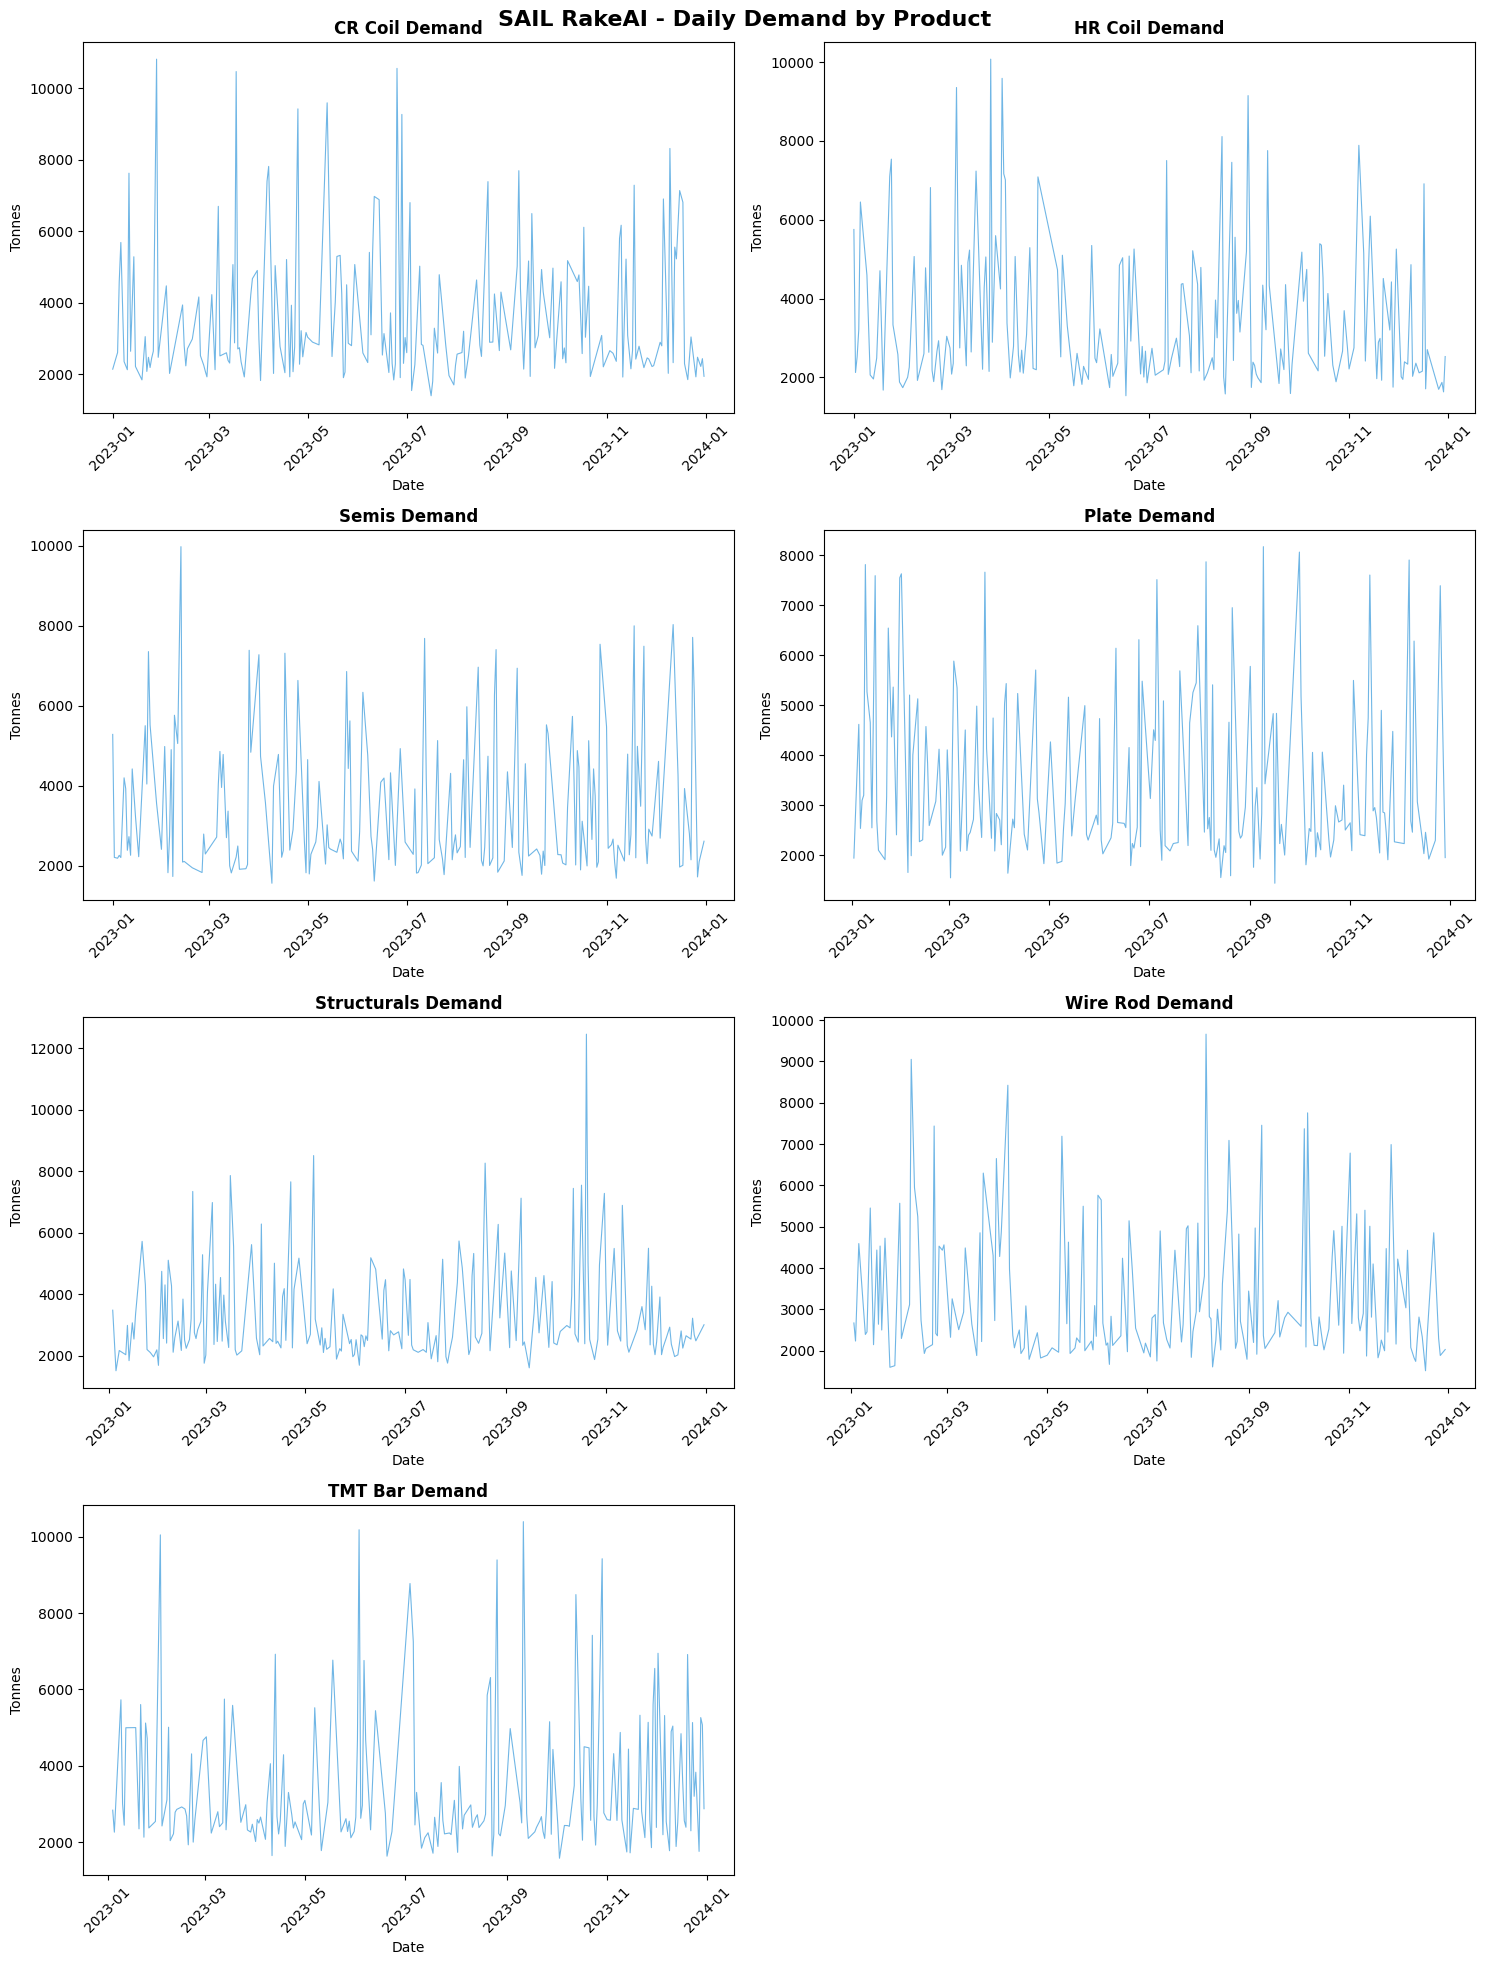

 Plot saved


In [3]:

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
fig.suptitle('SAIL RakeAI - Daily Demand by Product', 
             fontsize=16, fontweight='bold')
axes = axes.flatten()

products = daily_demand['product'].unique()

for i, product in enumerate(products):
    product_data = daily_demand[daily_demand['product'] == product].copy()
    product_data = product_data.sort_values('date')
    
    axes[i].plot(product_data['date'], 
                 product_data['quantity'],
                 color='#3498db', linewidth=0.8, alpha=0.7)
    axes[i].set_title(f'{product} Demand', fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Tonnes')
    axes[i].tick_params(axis='x', rotation=45)


axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../ml/demand_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved")

In [4]:
# Test if time series is stationary (required for ARIMA)
# Using HR Coil as ex product

product_name = "HR Coil"
product_data = daily_demand[
    daily_demand['product'] == product_name
].copy().sort_values('date').set_index('date')

# Fill missing dates with 0
product_data = product_data.resample('D')['quantity'].sum().fillna(0)

# Augmented Dickey Fuller test
result = adfuller(product_data)

print(f"Stationarity Test for {product_name} ")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"\nConclusion:")
if result[1] < 0.05:
    print(" Series is STATIONARY (p < 0.05)")
    print("   ARIMA can be applied directly")
else:
    print(" Series is NON-STATIONARY (p > 0.05)")
    print("   Will use differencing in ARIMA (d=1)")

Stationarity Test for HR Coil 
ADF Statistic : -17.5763
p-value       : 0.0000

Conclusion:
 Series is STATIONARY (p < 0.05)
   ARIMA can be applied directly


In [5]:
# Train ARIMA for each product and store models
arima_models = {}
arima_results = {}

print(" Training ARIMA models for all products...\n")

for product in products:
    # Prepare time series
    product_data = daily_demand[
        daily_demand['product'] == product
    ].copy().sort_values('date').set_index('date')
    
    product_ts = product_data.resample('D')['quantity'].sum().fillna(0)
    
    # Train/test split - last 30 days as test
    train = product_ts[:-30]
    test  = product_ts[-30:]
    
    # Fit ARIMA model
    model = ARIMA(train, order=(2, 0, 2))
    fitted = model.fit()
    
    # Forecast next 30 days
    forecast = fitted.forecast(steps=30)
    
    # Calculate metrics
    mae  = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    
    arima_models[product]  = fitted
    arima_results[product] = {
        'mae':      round(mae, 2),
        'rmse':     round(rmse, 2),
        'forecast': forecast,
        'test':     test
    }
    
    print(f" {product:15s} → MAE: {mae:.2f} | RMSE: {rmse:.2f}")

print("\nAll ARIMA models trained")

 Training ARIMA models for all products...

 CR Coil         → MAE: 1901.78 | RMSE: 2522.87
 HR Coil         → MAE: 1300.68 | RMSE: 1702.52
 Semis           → MAE: 1881.60 | RMSE: 2357.23
 Plate           → MAE: 1798.17 | RMSE: 2301.93
 Structurals     → MAE: 1218.50 | RMSE: 1400.99
 Wire Rod        → MAE: 1332.77 | RMSE: 1533.67
 TMT Bar         → MAE: 1820.27 | RMSE: 2296.60

All ARIMA models trained


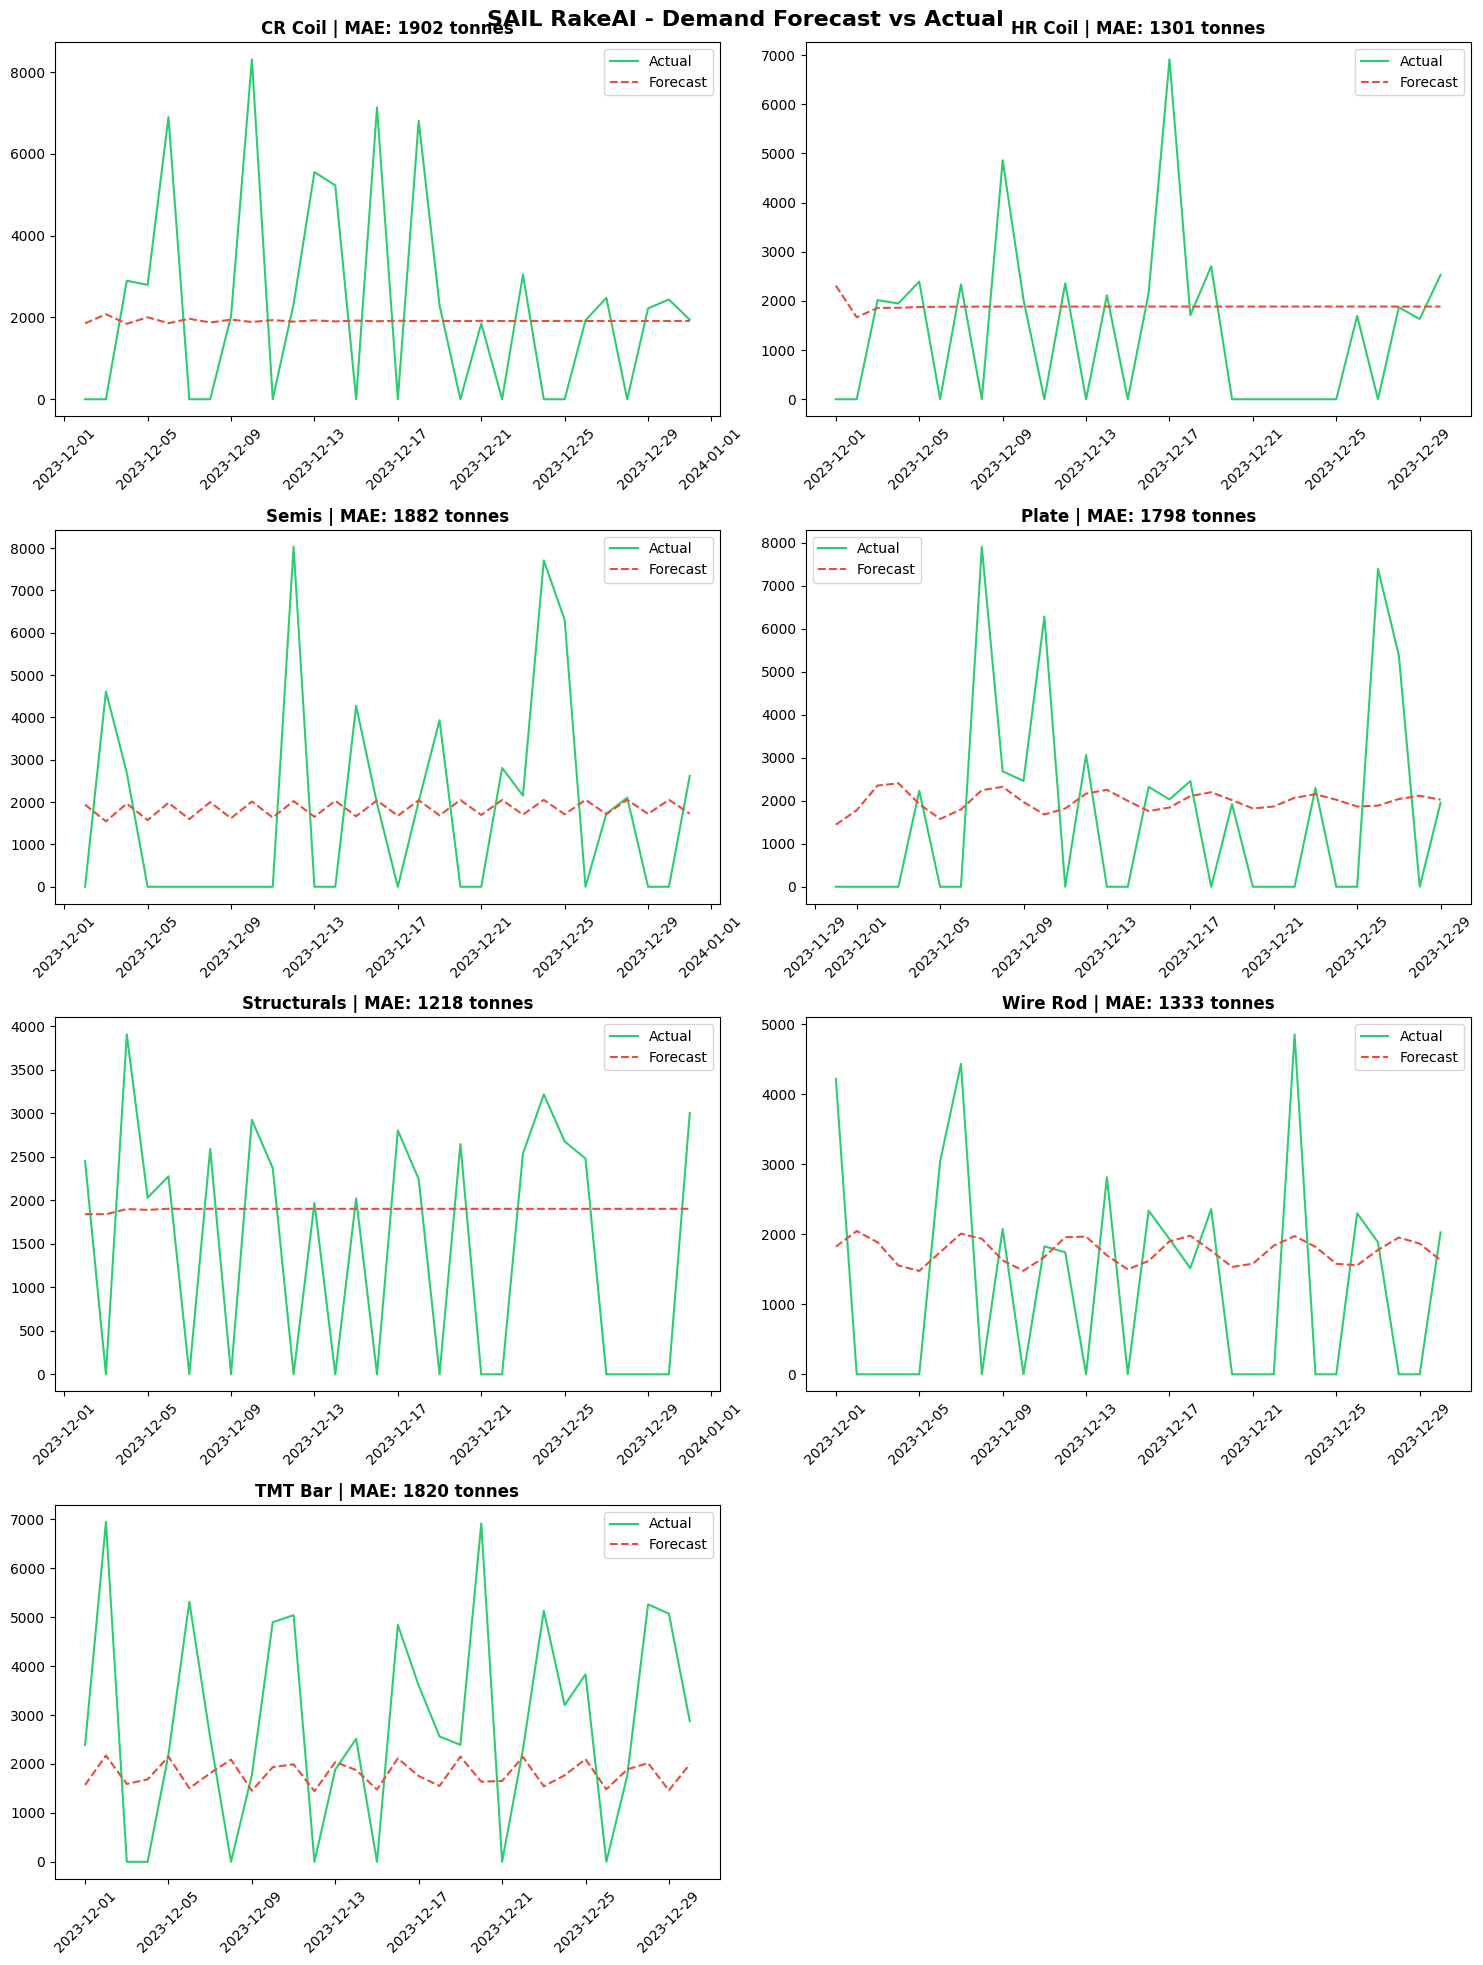

 Forecast plot saved


In [6]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
fig.suptitle('SAIL RakeAI - Demand Forecast vs Actual',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, product in enumerate(products):
    test     = arima_results[product]['test']
    forecast = arima_results[product]['forecast']
    mae      = arima_results[product]['mae']

    axes[i].plot(test.index, test.values,
                 label='Actual', color='#2ecc71', linewidth=1.5)
    axes[i].plot(test.index, forecast.values,
                 label='Forecast', color='#e74c3c', 
                 linewidth=1.5, linestyle='--')
    axes[i].set_title(f'{product} | MAE: {mae:.0f} tonnes',
                      fontweight='bold')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../ml/demand_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Forecast plot saved")

In [7]:

print("  SAIL RakeAI - Next 7 Day Demand Forecast")


next_7_days = {}

for product in products:
   
    product_data = daily_demand[
        daily_demand['product'] == product
    ].copy().sort_values('date').set_index('date')
    
    product_ts = product_data.resample('D')['quantity'].sum().fillna(0)
    
    # Fit on full data
    model  = ARIMA(product_ts, order=(2, 0, 2))
    fitted = model.fit()
    
    # Forecast next 7 days
    forecast = fitted.forecast(steps=7)
    forecast = [max(0, f) for f in forecast]  # no negative demand
    
    next_7_days[product] = forecast
    total = sum(forecast)
    
    print(f"\n {product}")
    print(f"   Total 7-day forecast: {total:.0f} tonnes")
    print(f"   Daily avg forecast:   {total/7:.0f} tonnes/day")

print("\n 7-day forecast complete")

  SAIL RakeAI - Next 7 Day Demand Forecast

 CR Coil
   Total 7-day forecast: 13857 tonnes
   Daily avg forecast:   1980 tonnes/day

 HR Coil
   Total 7-day forecast: 12979 tonnes
   Daily avg forecast:   1854 tonnes/day

 Semis
   Total 7-day forecast: 12556 tonnes
   Daily avg forecast:   1794 tonnes/day

 Plate
   Total 7-day forecast: 13873 tonnes
   Daily avg forecast:   1982 tonnes/day

 Structurals
   Total 7-day forecast: 13157 tonnes
   Daily avg forecast:   1880 tonnes/day

 Wire Rod
   Total 7-day forecast: 12105 tonnes
   Daily avg forecast:   1729 tonnes/day

 TMT Bar
   Total 7-day forecast: 13264 tonnes
   Daily avg forecast:   1895 tonnes/day

 7-day forecast complete


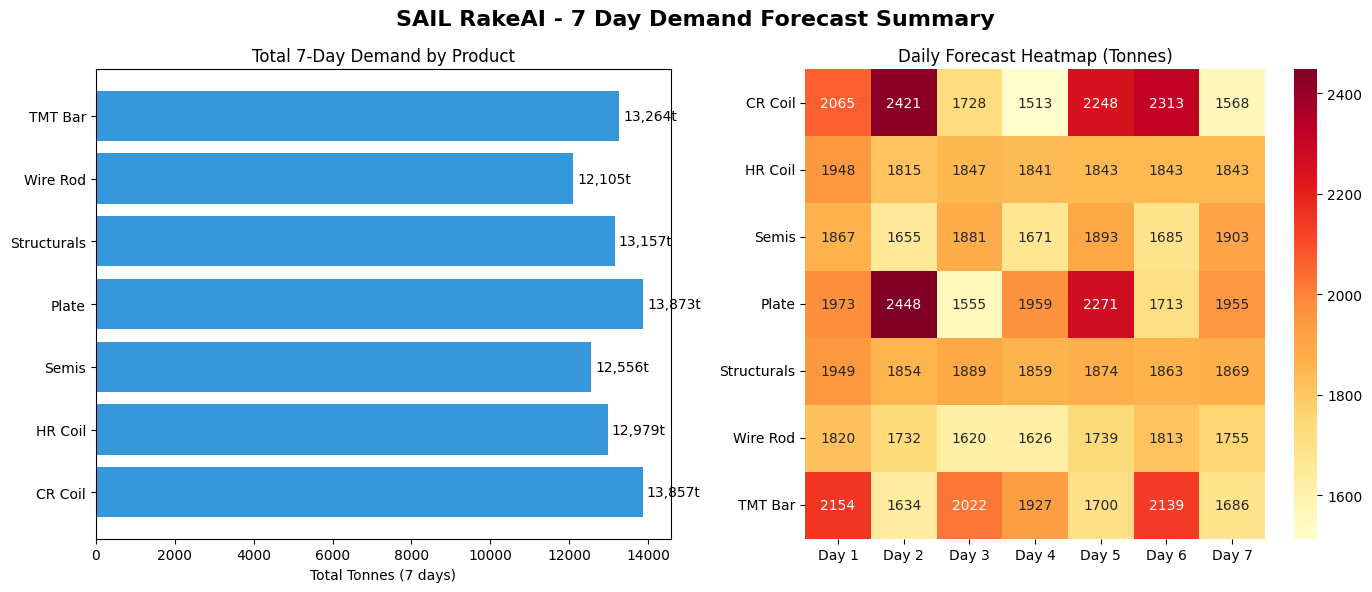

 Forecast summary saved!


In [8]:
products_list = list(next_7_days.keys())
totals = [sum(next_7_days[p]) for p in products_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('SAIL RakeAI - 7 Day Demand Forecast Summary',
             fontsize=16, fontweight='bold')

# Total forecast by product
axes[0].barh(products_list, totals, color='#3498db')
axes[0].set_xlabel('Total Tonnes (7 days)')
axes[0].set_title('Total 7-Day Demand by Product')
for i, v in enumerate(totals):
    axes[0].text(v + 100, i, f'{v:,.0f}t', va='center')

#  Daily forecast heatmap
forecast_matrix = np.array([next_7_days[p] for p in products_list])
days = [f'Day {i+1}' for i in range(7)]

sns.heatmap(forecast_matrix,
            xticklabels=days,
            yticklabels=products_list,
            annot=True, fmt='.0f',
            cmap='YlOrRd',
            ax=axes[1])
axes[1].set_title('Daily Forecast Heatmap (Tonnes)')

plt.tight_layout()
plt.savefig('../ml/7day_forecast_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Forecast summary saved!")

In [9]:
import joblib
import os

save_dir = '../ml/saved_models'
os.makedirs(save_dir, exist_ok=True)

for product, model in arima_models.items():
    filename = product.replace(' ', '_').lower()
    joblib.dump(model, f'{save_dir}/arima_{filename}.pkl')
    print(f" Saved ARIMA model for {product}")

# Save 7 day forecast as CSV
forecast_df = pd.DataFrame(next_7_days, 
                            index=[f'Day_{i+1}' for i in range(7)])
forecast_df.to_csv(f'{save_dir}/next_7_day_forecast.csv')

print(f"\nAll ARIMA models saved!")
print(f"\n Model Summary:")
print(f"   Algorithm  : ARIMA (2,0,2)")
print(f"   Products   : {len(products)} steel products")
print(f"   Forecast   : 7 days ahead")
print(f"\nMAE Summary:")
for product in products:
    mae = arima_results[product]['mae']
    print(f"   {product:15s} → MAE: {mae:.0f} tonnes")

 Saved ARIMA model for CR Coil
 Saved ARIMA model for HR Coil
 Saved ARIMA model for Semis
 Saved ARIMA model for Plate
 Saved ARIMA model for Structurals
 Saved ARIMA model for Wire Rod
 Saved ARIMA model for TMT Bar

All ARIMA models saved!

 Model Summary:
   Algorithm  : ARIMA (2,0,2)
   Products   : 7 steel products
   Forecast   : 7 days ahead

MAE Summary:
   CR Coil         → MAE: 1902 tonnes
   HR Coil         → MAE: 1301 tonnes
   Semis           → MAE: 1882 tonnes
   Plate           → MAE: 1798 tonnes
   Structurals     → MAE: 1218 tonnes
   Wire Rod        → MAE: 1333 tonnes
   TMT Bar         → MAE: 1820 tonnes
